# Refinement

A feedforward pass predicts every camera in one shot, which is a good first guess but not a
solved one. This page takes the scene's feedforward reconstruction and improves it two ways:
bundle adjustment refines the cameras against tracks across frames, and loop closure rebuilds
the sequence as overlapping submaps joined by a pose graph. Both return refined cameras and
points. Both are feedforward only; SfM backends already solve their poses globally.

In [1]:
import contextlib
import dataclasses
import io

import numpy as np
import pyvista as pv

from collab_splats.geometry.bundle_adjustment import (
    BundleAdjustment,
    BundleAdjustmentConfig,
)
from collab_splats.geometry.loop_closure.wrapper import LoopClosure, LoopClosureConfig
from collab_splats.geometry.transforms import invert_poses, umeyama_sim3
from collab_splats.pointcloud import PointcloudResult, get_creator
from collab_splats.pointcloud.utils import clean_pointcloud
from collab_splats.utils.torch_utils import pytorch_gc
from collab_splats.utils.visualization import (
    create_camera_frustum_pyvista,
    pointcloud_to_polydata,
)

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud")

## 1. Bundle adjustment

Bundle adjustment tracks points across frames with VGGSfM, then jointly refines the cameras
and the shared focal against three terms: reprojection error of the tracks, agreement with the
feedforward depth, and brightness between overlapping frames.

It reads the dense model-grid arrays (frames, confidence, per-pixel world points, depth), so
the zarr is loaded with them rather than through `scene.result`, which keeps only points and
cameras. The cells below follow the `refine` stage: refine the cameras, reproject the points
from the new cameras, then clean and cap them again. The scene itself is not rewritten; tracks
are cached in this page's work directory.

In [2]:
work = work_dir("refinement")
pc = scene.config["pointcloud"]

# Dense model-grid arrays, as the refine stage loads them
first = PointcloudResult.load_zarr(scene.pointcloud_zarr, load_images=True)

# Refine extrinsics and model-grid K; VGGSfM tracks need no full-res frame paths
ba_config = BundleAdjustmentConfig(tracks_cache_dir=work)
ba = BundleAdjustment(ba_config)

# VGGSfM, bae and torch.hub print every frame, step and load; keep the page to the summary below
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    extrinsics, intrinsics = ba.refine(
        first.images,
        first.confidence,
        first.world_points,
        first.extrinsics,
        first.model_intrinsics,
        first.image_paths,
        depth=first.depth,
    )

# Drop the stale full-res K, reproject under the new cameras, then clean and cap
refined = dataclasses.replace(
    first, extrinsics=extrinsics, model_intrinsics=intrinsics, intrinsics=None
)
refined = refined.reproject()
refined = clean_pointcloud(
    refined, remove_outliers=pc["clean"]["enabled"], max_points=pc["max_points"]
)

`ba.losses` holds the final loss of each term. The photometric term re-samples its pixels
during the solve, so losses from different steps do not compare; only the final values do.
The camera shift is measured against the diagonal of the trajectory's bounding box.

In [3]:
# Final loss per term
for term, loss in ba.losses.items():
    print(f"{term}: {loss:.4g}")

# Shared focal on the model grid
focal_before = first.model_intrinsics[0, 0, 0]
focal_after = refined.model_intrinsics[0, 0, 0]
print(f"focal {focal_before:.1f} -> {focal_after:.1f} px")

# Camera centers before and after, and the largest move relative to the trajectory extent
before = invert_poses(first.extrinsics)[:, :3, 3]
after = invert_poses(refined.extrinsics)[:, :3, 3]
span = np.ptp(before, axis=0)
extent = np.linalg.norm(span)
shift = np.linalg.norm(after - before, axis=1)
largest = shift.max() / extent
print(f"largest camera shift: {largest:.1%} of the trajectory extent")

reprojection: 2.123e+06
depth: 1.448e+07
photometric: 9.222e+05
focal 559.0 -> 559.1 px
largest camera shift: 2.0% of the trajectory extent


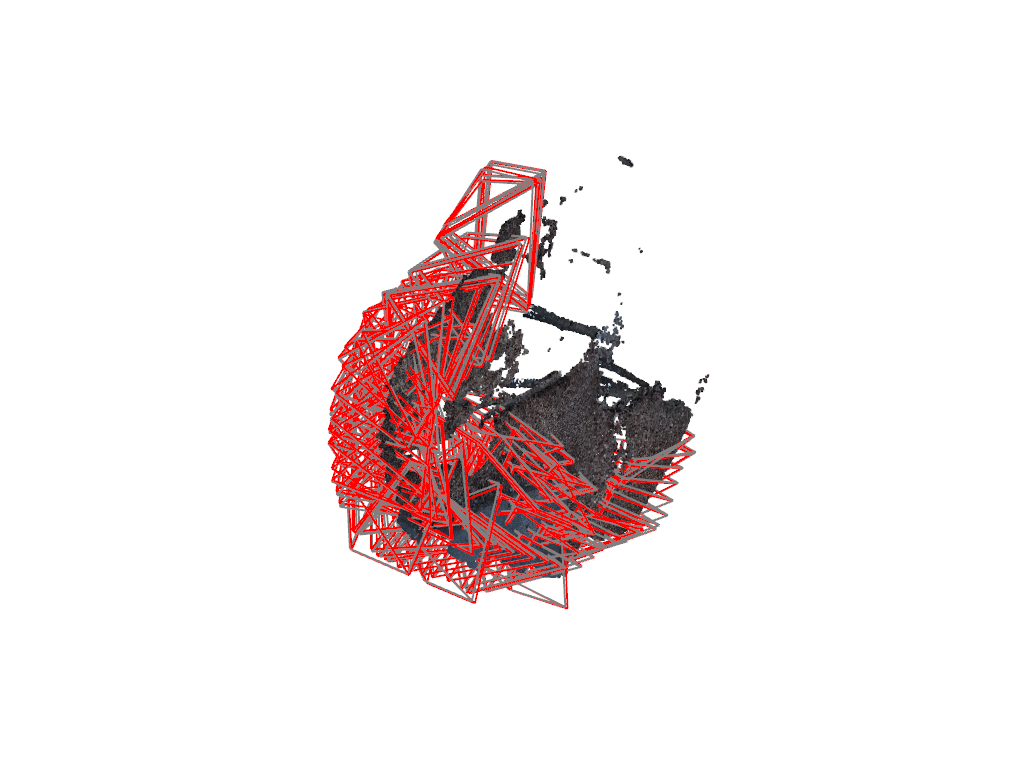

In [4]:
pl = pv.Plotter()

# Cameras before (grey) and after (red) bundle adjustment
for color, result in [("grey", first), ("red", refined)]:
    for w2c in result.extrinsics:
        frustum = create_camera_frustum_pyvista(w2c, scale=0.05)
        pl.add_mesh(frustum, color=color, line_width=2)

# Refined points in their own colors
cloud = pointcloud_to_polydata(refined.points, rgb=refined.colors)
pl.add_mesh(cloud, scalars="rgb", rgb=True, point_size=2)
pl.show()

Look for how far the red frustums sit from the grey ones; BA moves its result back onto the
input poses, so on a short clip with a good feedforward guess they land almost on top of each
other.

## 2. Loop closure

`LoopClosure` wraps a feedforward creator and keeps its `create_pointcloud` call. Instead of
one forward pass over every frame, it runs the model on overlapping submaps of `submap_size`
frames, with one frame shared between neighbors. Consecutive submaps are joined through that
shared frame. DINO-SALAD retrieval looks for revisits between non-adjacent submaps, and each
verified revisit adds a loop edge to the pose graph, which is then solved so the trajectory
closes on itself. Passing `ba=` bundle-adjusts each submap inside its window before it joins
the graph.
The first window refines the shared focal and every later window holds it fixed, so all
windows report the same focal.

The creator is built the way the `pointcloud` stage builds it, and the run writes into this
page's work directory.

In [5]:
# Free section 1's dense arrays; the trajectory plot keeps only `before`
del first, refined, ba
pytorch_gc()

# The scene's feedforward creator, built as the pointcloud stage builds it
creator_cls = get_creator(pc["backend"])
creator = creator_cls(
    max_points=pc["max_points"],
    min_views=pc["min_views"],
    mv_rel_thresh=pc["mv_rel_thresh"],
    clean=pc["clean"]["enabled"],
)

# Production loop-closure settings, with bundle adjustment inside each window
lc_config = LoopClosureConfig()
window_ba = BundleAdjustmentConfig()
lc = LoopClosure(base=creator, config=lc_config, ba=window_ba)

# Window solves and torch.hub loads print as they go; keep the page to the summary below
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    looped = lc.create_pointcloud(scene.images_dir, work / "loop_closure")

In [6]:
n_frames = len(looped.extrinsics)
print(f"{n_frames} frames, submap_size {lc.config.submap_size}")
# Set only when retrieval ran; a fallback single pass applies no loops
n_loops = getattr(lc, "n_loops_applied", 0)
print(f"loops applied: {n_loops}")

# One record per bundle-adjusted window
for record in lc.window_ba:
    print(
        f"window at frame {record['start']}: {record['n_frames']} frames, "
        f"ok {record['ok']}, focal {record['focal']:.1f} px"
    )

96 frames, submap_size 20
loops applied: 3
window at frame 0: 21 frames, ok True, focal 549.7 px
window at frame 20: 21 frames, ok True, focal 549.7 px
window at frame 40: 21 frames, ok True, focal 549.7 px
window at frame 60: 21 frames, ok True, focal 549.7 px
window at frame 80: 16 frames, ok True, focal 549.7 px


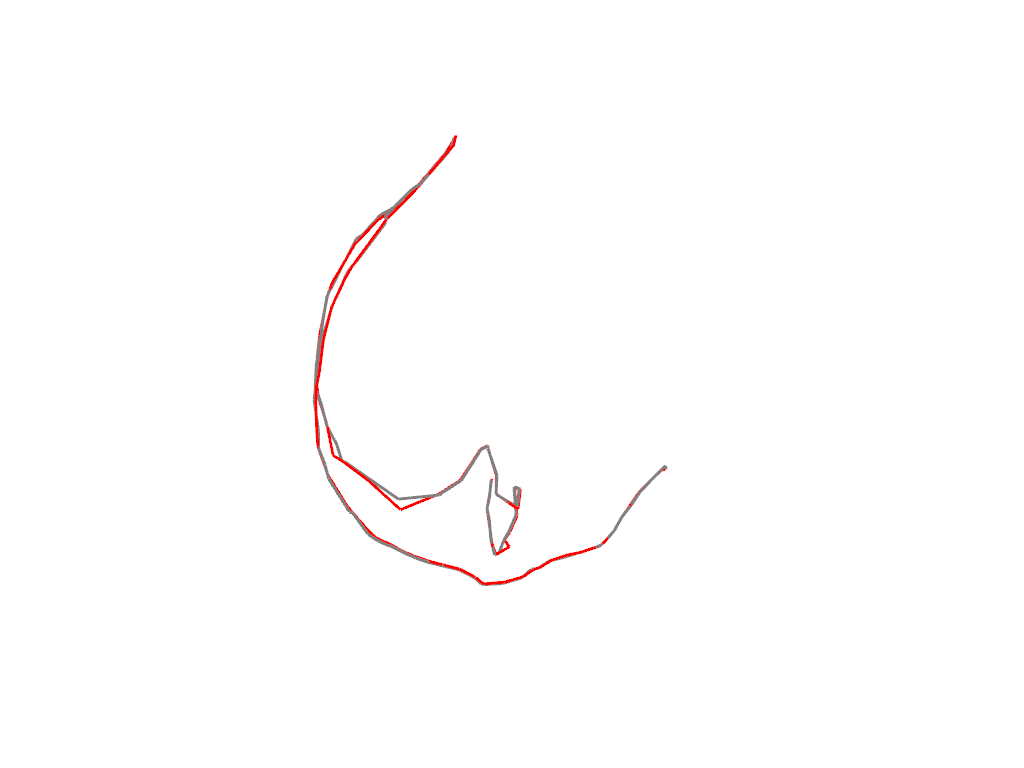

In [7]:
pl = pv.Plotter()

# Loop-closure centers moved onto the single pass by a similarity fit (scale, rotation, shift)
looped_centers = invert_poses(looped.extrinsics)[:, :3, 3]
scale, rotation, translation = umeyama_sim3(looped_centers, before)
rotated = looped_centers @ rotation.T
aligned = scale * rotated + translation

# Camera trajectories from the single pass (grey) and from loop closure (red)
single_path = pv.lines_from_points(before)
looped_path = pv.lines_from_points(aligned)
pl.add_mesh(single_path, color="grey", line_width=3)
pl.add_mesh(looped_path, color="red", line_width=3)
pl.show()

Each run sets its own scale and origin, so the red path is fitted onto the grey one before
drawing; look for drift at the far end of the grey path that the red path removes where a loop
was found.

## In a pipeline run

```yaml
pointcloud:
  bundle_adjustment: {enabled: true}
```

This runs the `refine` stage, which rewrites `pointcloud.zarr` and writes `colmap/refine.json`.
With `loop_closure: {enabled: true}` as well, bundle adjustment runs per window inside loop
closure instead and there is no `refine` stage. VGGSfM is the default `track_source`; the
matchers (`xfeat`, `loma`) are the alternatives.